## Goal and roadmap

We will learn the core math behind neural networks by solving a concrete task: teaching a computer to recognize handwritten digits from MNIST. Each image is 28 by 28 pixels, so the network receives 784 input numbers. It returns 10 output activations, one for each digit from 0 to 9.

The notebook follows this path:

1. define a single artificial neuron and the sigmoid activation;
2. stack neurons into a multilayer perceptron (MLP);
3. measure mistakes with a cost function;
4. minimize that cost with mini-batch stochastic gradient descent;
5. derive backpropagation, the algorithm that computes all gradients efficiently.

The implementation is intentionally small: no deep-learning framework, just NumPy and the chain rule.


This notebook is based on Michael Nielsen's online book [Neural Networks and Deep Learning](http://neuralnetworksanddeeplearning.com/chap1.html), with extra connective explanation around notation, SGD, and backpropagation.


## A single neuron: weighted sum plus sigmoid

A neuron first computes a weighted sum of its inputs and a bias,

$$
z = w \cdot x + b,
$$

and then passes that number through an activation function. Here we use the sigmoid

$$
\sigma(z) = \frac{1}{1 + e^{-z}}.
$$

The sigmoid maps any real value to the interval $(0, 1)$. Its derivative has a convenient form,

$$
\sigma'(z) = \sigma(z)(1 - \sigma(z)),
$$

which is one reason it is friendly for a first backpropagation implementation.


In [18]:
import plotly.graph_objects as go
from plotly.subplots import make_subplots
import numpy as np
from IPython.display import HTML

def show_plot(fig: go.Figure, height: int = 500) -> HTML:
    """Render Plotly as saved HTML so Quarto can publish the output."""
    fig.update_layout(
        height=height,
        margin={"l": 40, "r": 30, "t": 70, "b": 40},
    )
    return HTML(fig.to_html(include_plotlyjs="cdn", full_html=False))
x = np.linspace(-7, 7, 100)

In [19]:
def sigmoid(x: np.ndarray):
    """Get sigmoid function."""
    return 1 / (1 + np.exp(-x))

def sigmoid_prime(x: np.ndarray):
    """Return the derivative of the sigmoid function."""
    return sigmoid(x) * (1 - sigmoid(x))

fig = make_subplots(rows=2, cols=1)
fig.add_trace(go.Scatter(x=x, y=sigmoid(x), mode='lines', name='sigmoid'), row=1, col=1)
fig.add_trace(go.Scatter(x=x, y=sigmoid_prime(x), mode='lines', name='prime'), row=2, col=1)
fig.update_layout( 
    title="Sigmoid and its derivative",
    width=900,
    height=600,
)

show_plot(fig)

## From neurons to layers

A neural network is built by arranging neurons into layers. The leftmost layer is the **input layer**; for MNIST it contains 784 values, one per pixel. The rightmost layer is the **output layer**; here it contains 10 neurons, one per possible digit. Any layer between them is a **hidden layer**.

The word "hidden" does not mean mysterious. It only means that the desired labels do not directly tell us what those neurons should output; the network has to discover useful intermediate features during training.


![neural network](data/output.svg)

The network above is a **multilayer perceptron** (MLP): a feed-forward network where every neuron in one layer is connected to every neuron in the next layer. "Feed-forward" means information moves left to right during prediction; there are no cycles or recurrent connections.

A layer-size tuple such as `(784, 30, 10)` means: 784 input values, one hidden layer with 30 neurons, and 10 output neurons.


## Measuring mistakes with a cost function

Let $a(x)$ be the network output for an input image $x$, and let $y(x)$ be the desired one-hot vector. For example, if the image is a 7, then the target vector has a 1 in position 7 and 0 everywhere else.

We define the mean squared error (also called the quadratic cost) as

$$
C(w, b) = \frac{1}{2n}\sum_x \lVert y(x) - a(x) \rVert^2,
$$

where $n$ is the number of training examples. The factor $\frac{1}{2}$ is not essential; it just cancels the 2 that appears when differentiating the squared norm.

When $C$ is small, the network's outputs are close to the desired labels. Training means changing the weights $w$ and biases $b$ so that this cost becomes smaller.


## Gradient descent update

For each parameter we move in the direction that decreases the cost most quickly:

$$
w_k \leftarrow w_k - \eta \frac{\partial C}{\partial w_k}
$$

$$
b_k \leftarrow b_k - \eta \frac{\partial C}{\partial b_k}
$$

Here $\eta$ is the learning rate. If it is too small, learning is slow; if it is too large, the update can jump over good solutions or make training unstable.


Repeating this update is the basic "roll downhill" picture of gradient descent. The important practical question is how to compute the gradient.

Computing the exact gradient over the full training set after every tiny update is expensive, so neural networks usually use a cheaper approximation: mini-batch stochastic gradient descent.


## Mini-batch stochastic gradient descent

Stochastic gradient descent randomly picks a small mini-batch of $m$ training examples. Call them $X_1, X_2, \ldots, X_m$. The average gradient on this mini-batch is used as an estimate of the full training-set gradient:

$$
\frac{1}{m} \sum_{j=1}^m \nabla C_{X_j} \approx \frac{1}{n} \sum_x \nabla C_x = \nabla C.
$$

The update is therefore noisy, but much cheaper. That noise is often useful: it lets training make frequent progress and sometimes helps the optimizer avoid shallow bad regions.

In the code below, one **epoch** means one pass over the shuffled training data. Each mini-batch calls `backprop` once per example, accumulates the gradients, averages them, and applies the update.


In [ ]:
from tqdm import tqdm

In [ ]:
class Network(object):

    def __init__(self, sizes: tuple):
        """Create a network object.
        
        :param sizes: Sizes of the corresponding layers.
        """
        self.num_layers = len(sizes)
        self.biases = [np.random.randn(y, 1) for y in sizes[1:]] # skip 0 layer, it is an input layer
        self.weights = [
            np.random.randn(y, x)
            for x, y in zip(sizes[:-1], sizes[1:])
        ]
    
    def feed_forward(self, input: np.array):
        """Return the output of the network.
        
        :param input: input to the network
        """
        output = input
        for b, w in zip(self.biases, self.weights):
            output = sigmoid(np.dot(w, output) + b)
        
        return output
    
    def SGD(
        self,
        training_data,
        epochs,
        mini_batch_size,
        learning_rate,
        test_data=None,
        ):
        """Train the neural network using mini-batch stochastic gradient descent.

        :param training_data: List of pairs ``(x, y)``, where ``x`` is a training input
        and ``y`` is the desired output.
        :param epochs: Number of training epochs.
        :param mini_batch_size: Size of each mini-batch.
        :param learning_rate: Learning rate used during gradient descent.
        :param test_data: Optional test dataset used to evaluate the network after each epoch.
        """
        training_data_size = len(training_data)

        if test_data is not None:
            test_data_size = len(test_data)

        for epoch_index in range(epochs):
            np.random.shuffle(training_data)

            mini_batches = [
                training_data[start_index: start_index + mini_batch_size]
                for start_index in range(0, training_data_size, mini_batch_size)
            ]

            for mini_batch in mini_batches:
                self.update_mini_batch(mini_batch, learning_rate)

            if test_data is not None:
                correct_predictions = self.evaluate(test_data)
                print(f"Epoch {epoch_index}: {correct_predictions} / {test_data_size}")
            else:
                print(f"Epoch {epoch_index} complete")
    
    def update_mini_batch(self, mini_batch, eta):
        """Update weights and biases by applying GD using backprop to a single mini batch.

        The "mini_batch" is a list of tuples "(x, y)", and "eta" is the learning rate.
        """
        nabla_b = [np.zeros_like(b) for b in self.biases]
        nabla_w = [np.zeros_like(w) for w in self.weights]

        for x, y in mini_batch:
            delta_nabla_b, delta_nabla_w = self.backprop(x, y)
    
            nabla_b = [nb + dnb for nb, dnb in zip(nabla_b, delta_nabla_b)]
            nabla_w = [nw + dnw for nw, dnw in zip(nabla_w, delta_nabla_w)]

        self.weights = [
            w - (eta / len(mini_batch)) * nw 
            for w, nw in zip(self.weights, nabla_w)
        ]
        self.biases = [
            b - (eta/len(mini_batch)) * nb 
            for b, nb in zip(self.biases, nabla_b)
            ]
    
    def backprop(self, x, y):
        """Return a tuple ``(nabla_b, nabla_w)`` representing the
        gradient for the cost function C_x.
        ``nabla_b`` and ``nabla_w`` are layer-by-layer lists of numpy arrays,
        similar to ``self.biases`` and ``self.weights``.
        """
        nabla_b = [np.zeros(b.shape) for b in self.biases]
        nabla_w = [np.zeros(w.shape) for w in self.weights]
        # feedforward
        activation = x
        activations = [x] # list to store all the activations, layer by layer
        zs = [] # list to store all the z vectors, layer by layer
        for b, w in zip(self.biases, self.weights):
            z = np.dot(w, activation) + b
            zs.append(z)
            activation = sigmoid(z)
            activations.append(activation)
        # backward pass
        delta = self.cost_derivative(activations[-1], y) * \
            sigmoid_prime(zs[-1])
        nabla_b[-1] = delta
        nabla_w[-1] = np.dot(delta, activations[-2].transpose())
        # Note that the variable l in the loop below is used a little
        # differently to the notation in Chapter 2 of the book.  Here,
        # l = 1 means the last layer of neurons, l = 2 is the
        # second-last layer, and so on.  It's a renumbering of the
        # scheme in the book, used here to take advantage of the fact
        # that Python can use negative indices in lists.
        for l in range(2, self.num_layers):
            z = zs[-l]
            sp = sigmoid_prime(z)
            delta = np.dot(self.weights[-l+1].transpose(), delta) * sp
            nabla_b[-l] = delta
            nabla_w[-l] = np.dot(delta, activations[-l-1].transpose())
        return (nabla_b, nabla_w)

    def evaluate(self, test_data):
        """Return the number of test inputs for which the neural
        network outputs the correct result. Note that the neural
        network's output is assumed to be the index of whichever
        neuron in the final layer has the highest activation."""
        test_results = [
            (np.argmax(self.feed_forward(x)), y)
            for (x, y) in test_data
            ]
        return sum(int(x == y) for (x, y) in test_results)

    def cost_derivative(self, output_activations, y):
        """Return the vector of partial derivatives partial C_x /
        partial a for the output activations."""
        return (output_activations - y)


The class stores one weight matrix for each pair of neighboring layers. If `sizes = (784, 30, 10)`, then:

- `weights[0]` has shape `(30, 784)` and connects the input layer to the hidden layer;
- `weights[1]` has shape `(10, 30)` and connects the hidden layer to the output layer;
- `biases[0]` has shape `(30, 1)` and `biases[1]` has shape `(10, 1)`.

In mathematical notation, $w^l_{jk}$ is the weight from neuron $k$ in layer $l-1$ to neuron $j$ in layer $l$. This row/column convention matches `np.dot(w, activation) + b` in `feed_forward`.


In [33]:
from pathlib import Path
import pickle

import numpy as np


def load_data(path: str | Path = "../data/mnist.pkl"):
    """
    Load MNIST data from an unpacked pickle file.

    :param path: Path to the unpacked MNIST pickle file, usually ``mnist.pkl``.
    :return: Tuple ``(training_data, validation_data, test_data)``.
    """

    path = Path(path)

    with path.open("rb") as file:
        training_data, validation_data, test_data = pickle.load(
            file,
            encoding="latin1",
        )

    return training_data, validation_data, test_data


def load_data_wrapper(path: str | Path = "../data/mnist.pkl"):
    """
    Load MNIST data and convert it to a format convenient for a neural network.

    :param path: Path to the unpacked MNIST pickle file.
    :return: Tuple ``(training_data, validation_data, test_data)``.

    ``training_data`` is a list of pairs ``(x, y)``, where:

    - ``x`` has shape ``(784, 1)``
    - ``y`` has shape ``(10, 1)`` and is a one-hot vector

    ``validation_data`` and ``test_data`` are lists of pairs ``(x, y)``, where:

    - ``x`` has shape ``(784, 1)``
    - ``y`` is an integer label from 0 to 9
    """

    training_raw, validation_raw, test_raw = load_data(path)

    training_inputs = [
        np.reshape(image, (784, 1))
        for image in training_raw[0]
    ]

    training_labels = [
        vectorized_result(label)
        for label in training_raw[1]
    ]

    training_data = list(zip(training_inputs, training_labels))

    validation_inputs = [
        np.reshape(image, (784, 1))
        for image in validation_raw[0]
    ]

    validation_data = list(zip(validation_inputs, validation_raw[1]))

    test_inputs = [
        np.reshape(image, (784, 1))
        for image in test_raw[0]
    ]

    test_data = list(zip(test_inputs, test_raw[1]))

    return training_data, validation_data, test_data


def vectorized_result(label: int) -> np.ndarray:
    """
    Convert a digit label to a one-hot column vector.

    :param label: Digit from 0 to 9.
    :return: A ``(10, 1)`` vector with 1.0 at the label position.
    """

    result = np.zeros((10, 1))
    result[label] = 1.0
    return result

In [37]:
training_data, validation_data, test_data = load_data_wrapper(
    "data/mnist/mnist.pkl"
)

len(training_data)

C:\Users\qweqw\AppData\Local\Temp\ipykernel_41244\2788249775.py:18: VisibleDeprecationWarning: dtype(): align should be passed as Python or NumPy boolean but got `align=0`. Did you mean to pass a tuple to create a subarray type? (Deprecated NumPy 2.4)
  training_data, validation_data, test_data = pickle.load(


50000

Now train a model with **one hidden layer of 30 neurons**. This is not 30 hidden layers; the tuple `(784, 30, 10)` describes three layers total: input, hidden, and output.


In [44]:
net = Network((784, 30, 10))

In [46]:
net.SGD(training_data, 40, 10, 3.0, test_data=test_data)

  2%|▎         | 1/40 [00:03<02:24,  3.70s/it]

Epoch 0: 9476 / 10000


  5%|▌         | 2/40 [00:07<02:20,  3.70s/it]

Epoch 1: 9459 / 10000


  8%|▊         | 3/40 [00:11<02:16,  3.70s/it]

...

Epoch 37: 9513 / 10000


 98%|█████████▊| 39/40 [02:27<00:03,  3.83s/it]

Epoch 38: 9515 / 10000


100%|██████████| 40/40 [02:31<00:00,  3.80s/it]

Epoch 39: 9512 / 10000


In [48]:
net = Network([784, 100, 10])
net.SGD(training_data, 30, 10, 3.0, test_data=test_data)

  3%|▎         | 1/30 [00:19<09:27, 19.56s/it]

Epoch 0: 6624 / 10000


  7%|▋         | 2/30 [00:41<09:40, 20.74s/it]

Epoch 1: 6791 / 10000


 10%|█         | 3/30 [01:00<09:07, 20.27s/it]

...

Epoch 27: 9640 / 10000


 97%|█████████▋| 29/30 [09:40<00:19, 19.61s/it]

Epoch 28: 9640 / 10000


100%|██████████| 30/30 [09:59<00:00, 19.99s/it]

Epoch 29: 9655 / 10000


In [49]:
net = Network([784, 10])
net.SGD(training_data, 30, 10, 3.0, test_data=test_data)

  3%|▎         | 1/30 [00:03<01:39,  3.42s/it]

Epoch 0: 4293 / 10000


  7%|▋         | 2/30 [00:05<01:08,  2.45s/it]

Epoch 1: 5679 / 10000


 10%|█         | 3/30 [00:06<00:57,  2.12s/it]

...

Epoch 27: 8388 / 10000


 97%|█████████▋| 29/30 [00:53<00:01,  1.75s/it]

Epoch 28: 8403 / 10000


100%|██████████| 30/30 [00:54<00:00,  1.83s/it]

Epoch 29: 8399 / 10000


## Backpropagation: why it is needed

The `Network` class above calls `backprop` inside every mini-batch update. Backpropagation is the efficient way to compute the derivatives needed by gradient descent:

$$
\frac{\partial C}{\partial w^l_{jk}}, \qquad \frac{\partial C}{\partial b^l_j}.
$$

A naive approach would perturb one weight at a time and see how the cost changes. That would require a separate forward pass for every parameter. Backpropagation avoids this by reusing intermediate values from one forward pass and then applying the chain rule backward through the layers.

Historically, the idea appeared before the 1980s, but the 1986 paper by David Rumelhart, Geoffrey Hinton, and Ronald Williams made its practical importance much clearer. Today it is the standard engine behind neural-network training.


## Layer notation

Number the layers from $0$ to $L$. Layer $0$ is the input layer; layer $L$ is the output layer.

We use $w^l_{jk}$ for the weight from neuron $k$ in layer $l-1$ to neuron $j$ in layer $l$.

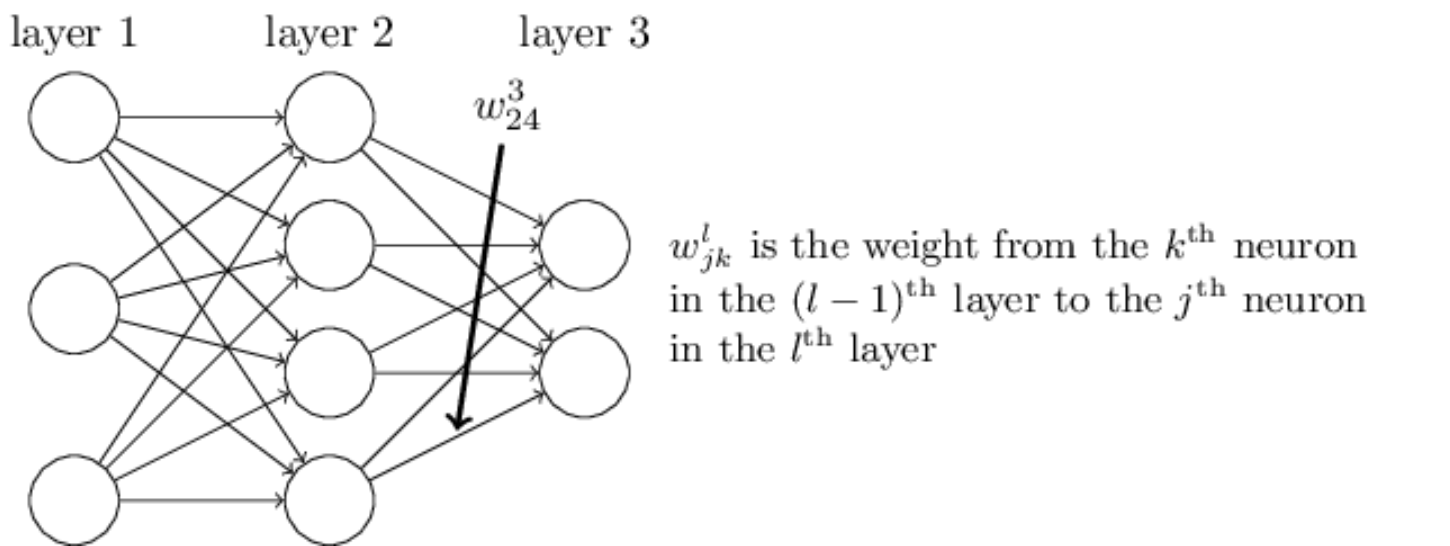


We use similar notation for biases and activations:

- $b^l_j$ is the bias of neuron $j$ in layer $l$;
- $a^l_j$ is the activation of neuron $j$ in layer $l$;
- $a^0$ is the input vector $x$.

It is also useful to name the pre-activation value $z^l_j$, the weighted input before the sigmoid is applied.

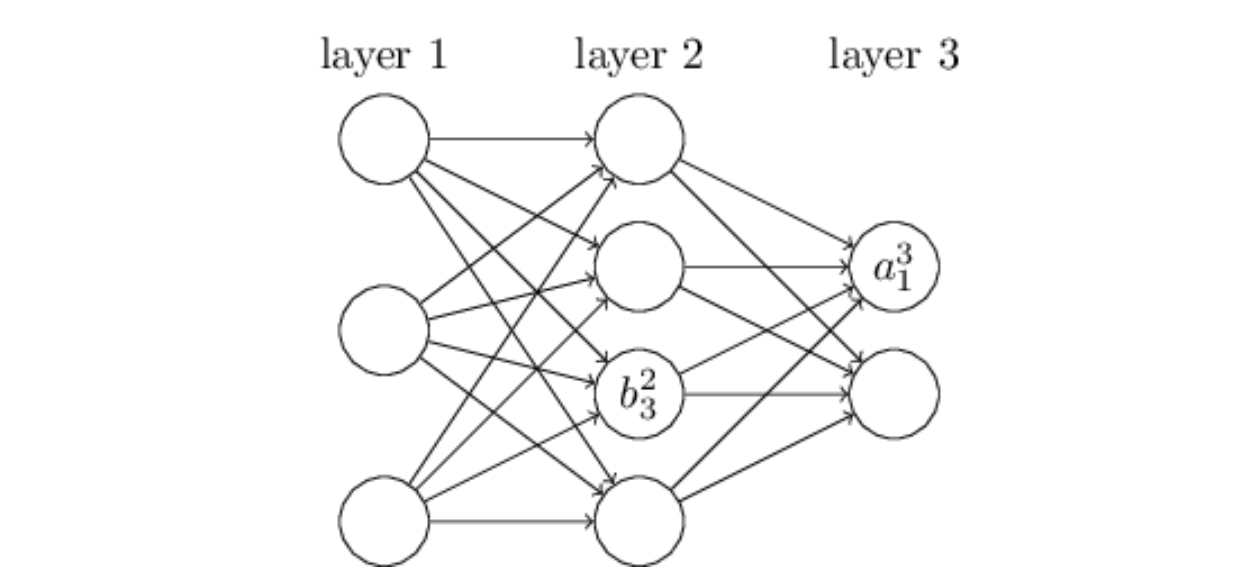


For a single neuron, the computation in layer $l$ is

$$
z^l_j = \sum_k w^l_{jk} a^{l-1}_k + b^l_j,
$$

followed by

$$
a^l_j = \sigma(z^l_j).
$$

This is the same calculation performed in the `feed_forward` method.


In matrix form, $w^l$ has shape `(number of neurons in layer l, number of neurons in layer l-1)`. The vectors $b^l$, $z^l$, and $a^l$ all have one row per neuron in layer $l$.

This shape convention is why the forward step is written as a matrix-vector product: rows of $w^l$ correspond to destination neurons, columns correspond to source neurons.


With that notation the whole layer is

$$
z^l = w^l a^{l-1} + b^l,
$$

and

$$
a^l = \sigma(z^l),
$$

where $\sigma$ is applied element by element.


For one training example, the quadratic cost is

$$
C_x = \frac{1}{2}\lVert y - a^L \rVert^2.
$$

The full cost $C$ is the average of $C_x$ over the training set. Backpropagation computes gradients for one example, and mini-batch SGD averages those gradients across the mini-batch before updating the parameters.


The key intermediate quantity is the **error**

$$
\delta^l_j = \frac{\partial C}{\partial z^l_j}.
$$

This is not the raw prediction error $y_j - a_j$. It measures how sensitive the cost is to the weighted input $z^l_j$ of a neuron. We define the error with respect to $z$ because every weight and bias affects the cost by first changing $z$, then changing the activation, and only then changing the final cost.


## The four backpropagation equations

Backpropagation is built around four equations. Here $L$ is the final layer, and $\odot$ means element-wise multiplication.

**1. Output-layer error**

$$
\delta^L = \nabla_a C \odot \sigma'(z^L).
$$

For the quadratic cost,

$$
\nabla_a C = a^L - y,
$$

so

$$
\delta^L = (a^L - y) \odot \sigma'(z^L).
$$

**2. Hidden-layer error from the next layer**

$$
\delta^l = ((w^{l+1})^T\delta^{l+1}) \odot \sigma'(z^l).
$$

The transpose moves the error signal backward through the same weights that carried activations forward.

**3. Bias gradient**

$$
\frac{\partial C}{\partial b^l_j} = \delta^l_j.
$$

In vector form, $\nabla_{b^l} C = \delta^l$.

**4. Weight gradient**

$$
\frac{\partial C}{\partial w^l_{jk}} = \delta^l_j a^{l-1}_k.
$$

In matrix form,

$$
\nabla_{w^l} C = \delta^l (a^{l-1})^T.
$$


## Where the equations come from

For the output layer, apply the chain rule directly:

$$
\delta^L_j = \frac{\partial C}{\partial z^L_j}
= \frac{\partial C}{\partial a^L_j}\frac{\partial a^L_j}{\partial z^L_j}
= (a^L_j - y_j)\sigma'(z^L_j).
$$

For a hidden layer, the cost depends on $a^l_j$ only through the weighted inputs in the next layer:

$$
z^{l+1}_k = \sum_j w^{l+1}_{kj}a^l_j + b^{l+1}_k.
$$

So another application of the chain rule gives

$$
\frac{\partial C}{\partial a^l_j}
= \sum_k \frac{\partial C}{\partial z^{l+1}_k}\frac{\partial z^{l+1}_k}{\partial a^l_j}
= \sum_k \delta^{l+1}_k w^{l+1}_{kj}.
$$

Then we multiply by the local derivative of the activation:

$$
\delta^l_j
= \frac{\partial C}{\partial z^l_j}
= \left(\sum_k w^{l+1}_{kj}\delta^{l+1}_k\right)\sigma'(z^l_j).
$$

This is exactly the vector equation $\delta^l = ((w^{l+1})^T\delta^{l+1}) \odot \sigma'(z^l)$.

The gradients for biases and weights are simpler because

$$
z^l_j = \sum_k w^l_{jk}a^{l-1}_k + b^l_j.
$$

Therefore $\partial z^l_j / \partial b^l_j = 1$ and $\partial z^l_j / \partial w^l_{jk} = a^{l-1}_k$, which gives the bias and weight gradient equations above.


## Backpropagation as an algorithm

For one training example $(x, y)$, the algorithm is:

1. Run a forward pass and store every $z^l$ and $a^l$.
2. Compute the output error $\delta^L$.
3. Move backward layer by layer, computing $\delta^{L-1}, \delta^{L-2}, \ldots, \delta^1$.
4. Convert each layer's $\delta^l$ into gradients: $\nabla_{b^l} C = \delta^l$ and $\nabla_{w^l} C = \delta^l(a^{l-1})^T$.
5. Return those gradients to the SGD step, which averages them over the mini-batch and updates the network.

The forward pass tells us what the network did. The backward pass tells us how each parameter contributed to the mistake.


## How this matches the code

The implementation in `Network.backprop` follows the algorithm almost line by line:

- `activations = [x]` stores $a^0, a^1, \ldots, a^L$;
- `zs` stores $z^1, z^2, \ldots, z^L$;
- `cost_derivative(activations[-1], y) * sigmoid_prime(zs[-1])` computes $\delta^L$;
- `nabla_b[-1] = delta` applies $\nabla_{b^L} C = \delta^L$;
- `np.dot(delta, activations[-2].transpose())` applies $\nabla_{w^L} C = \delta^L(a^{L-1})^T$;
- the loop over `l` walks backward through earlier layers using `self.weights[-l+1].transpose()`, the code version of $(w^{l+1})^T$.

The negative indexes can look awkward at first, but they only mean "count layers from the end." The math is the same as the equations above.


## Why backpropagation is efficient

A network with architecture `(784, 30, 10)` already has $30 \cdot 784 + 10 \cdot 30 = 23,820$ weights, plus 40 biases. Estimating each derivative separately would require tens of thousands of extra forward passes per training example.

Backpropagation computes all those derivatives with one forward pass and one backward pass. That is the core reason neural networks can be trained in practice.


## Matrix multiplication note

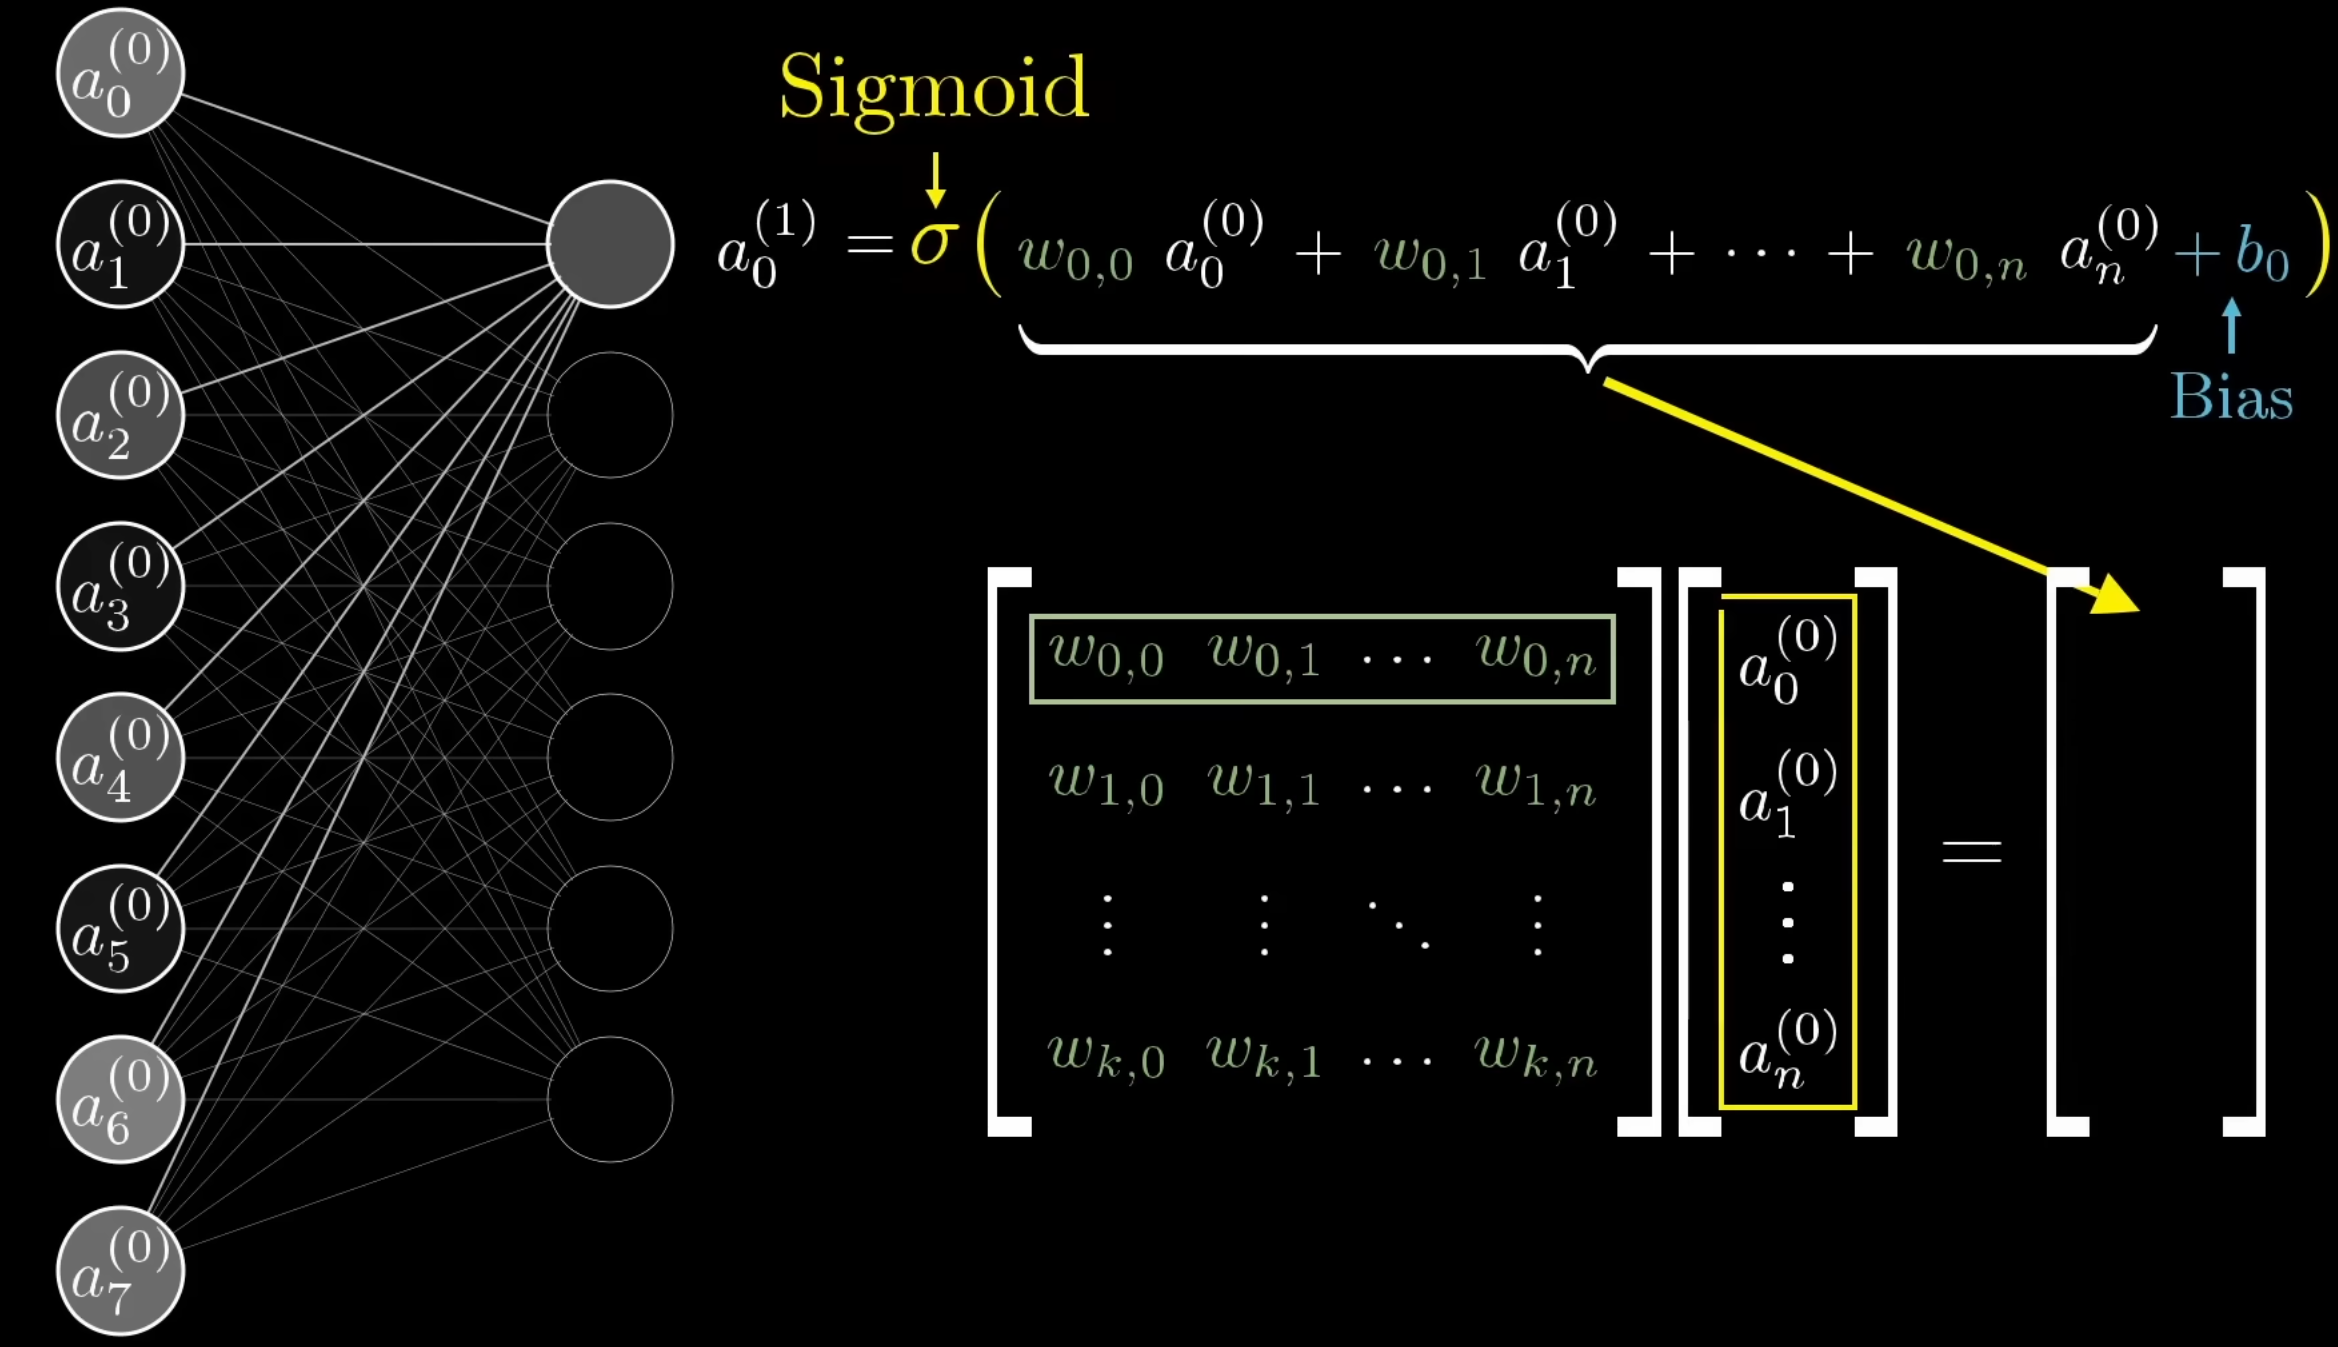

In the weight matrix $w$, each row contains all weights that feed into one neuron in the next layer. Multiplying $w^l a^{l-1}$ computes every neuron's weighted input for layer $l$ at once.
